In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
n = 1000
d = 50

X = np.random.randn(n, d)
true_w = np.random.randn(d)
y = X @ true_w + 0.1 * np.random.randn(n)

lam = 1e-2

In [3]:
def f_i(w, i):
    return 0.5 * (X[i] @ w - y[i])**2 + (lam/2) * np.linalg.norm(w)**2

def grad_f_i(w, i):
    return (X[i] @ w - y[i]) * X[i] + lam * w

def full_grad(w):
    return np.mean([grad_f_i(w, i) for i in range(n)], axis=0)

def loss(w):
    return np.mean([f_i(w, i) for i in range(n)])

In [4]:
def SAG(w_init, lr, epochs):
    w = w_init.copy()
    memory = np.zeros((n, d))
    grad_avg = np.zeros(d)
    history = []
    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)
            grad_new = grad_f_i(w, i)
            grad_avg += (grad_new - memory[i]) / n
            memory[i] = grad_new
            w -= lr * grad_avg
        history.append(loss(w))
    return w, history

In [5]:
def SAGA(w_init, lr, epochs):
    w = w_init.copy()
    memory = np.zeros((n, d))
    grad_avg = np.zeros(d)
    history = []
    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)
            grad_new = grad_f_i(w, i)
            gk = grad_new - memory[i] + grad_avg
            grad_avg += (grad_new - memory[i]) / n
            memory[i] = grad_new
            w -= lr * gk
        history.append(loss(w))
    return w, history

In [6]:
def SVRG(w_init, lr, epochs, m):
    w = w_init.copy()
    history = []
    for epoch in range(epochs):
        w_tilde = w.copy()
        mu = full_grad(w_tilde)
        w_inner = w_tilde.copy()
        for _ in range(m):
            i = np.random.randint(0, n)
            grad = grad_f_i(w_inner, i) - grad_f_i(w_tilde, i) + mu
            w_inner -= lr * grad
        w = w_inner
        history.append(loss(w))
    return w, history

In [7]:
w0 = np.zeros(d)

lr = 0.01
epochs = 20
m = n

w_sag, hist_sag = SAG(w0, lr, epochs)
w_saga, hist_saga = SAGA(w0, lr, epochs)
w_svrg, hist_svrg = SVRG(w0, lr, epochs, m)

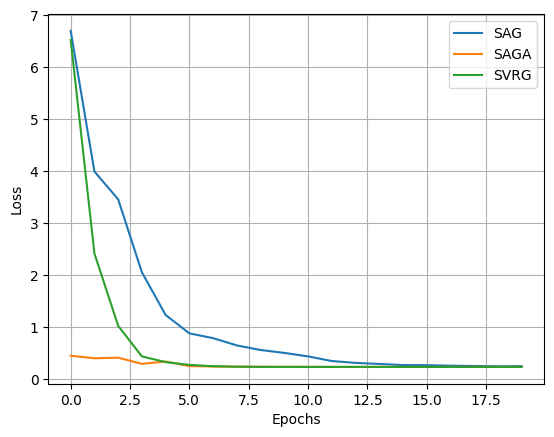

In [8]:
plt.plot(hist_sag, label="SAG")
plt.plot(hist_saga, label="SAGA")
plt.plot(hist_svrg, label="SVRG")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [9]:
print(np.linalg.norm(w_sag - true_w))
print(np.linalg.norm(w_saga - true_w))
print(np.linalg.norm(w_svrg - true_w))

0.17116704692419862
0.07844704759962656
0.07844092111250707
